# MLP FeedForward Training for Spirob (13-Joint Configuration)

Reines MLP-Netzwerk ohne Windowing — jeder Timestep wird einzeln vorhergesagt.

In [291]:
import polars as pl
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import matplotlib.pyplot as plt
import joblib, json, os, copy
from datetime import datetime

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [292]:
# ==================== CONFIGURATION ====================

FILE_PATHS = [
    #"runs/2026-02-05_14-46-22/merged_smoothed.csv",
    #"runs/2026-02-06_14-14-43/merged_smoothed.csv",
    #"runs/2026-02-09_12-34-53/merged_smoothed.csv",
    #"runs/2026-02-10_12-14-57/merged_smoothed.csv",
    #"runs/2026-02-11_17-22-11/merged.csv",
    "runs/2026-02-16_12-20-17/merged_smoothed.csv",
    "runs/2026-02-16_15-19-31/merged_smoothed.csv",
    "runs/2026-02-16_16-58-18/merged_smoothed.csv",
    "runs/2026-02-19_10-14-37/merged_smoothed.csv"
    
    
]

FEATURE_SELECTION = ["magX","magY","magZ"]
SENSOR_ID_FILTER = None  # None = alle Sensoren

# Training
VAL_SIZE = 0.2
TEST_SIZE = 0.2
RANDOM_SEED = 41
BATCH_SIZE = 32
EPOCHS = 300
LEARNING_RATE = 0.001
WEIGHT_DECAY = 0.00001
EARLY_STOPPING_PATIENCE = 40

# MLP Architecture
HIDDEN_LAYERS = [256, 128, 64]  # Anzahl Neuronen pro Hidden Layer
DROPOUT_RATE = 0.2
ANGLE_WEIGHT_ALPHA = 0
PHYSICAL_ANGLE_LIMIT = 35

# Auto-detect theta columns
df_sample = pl.read_csv(FILE_PATHS[0], n_rows=1)
THETA_COLS = [c for c in df_sample.columns if c.startswith("theta_")]

print(f"\u2699\ufe0f  Config:")
print(f"   Files: {len(FILE_PATHS)} | Features: {FEATURE_SELECTION}")
print(f"   MLP Layers: {HIDDEN_LAYERS} | Dropout: {DROPOUT_RATE}")
print(f"   Output: {len(THETA_COLS)} joints")

⚙️  Config:
   Files: 4 | Features: ['magX', 'magY', 'magZ']
   MLP Layers: [256, 128, 64] | Dropout: 0.2
   Output: 13 joints


In [293]:
# ==================== LOAD AND PIVOT DATA ====================

def load_and_pivot_run(path, expected_sensors=None, sensor_filter=None):
    df = pl.read_csv(path)
    if "sensor_id" in df.columns:
        df = df.with_columns(pl.col("sensor_id").cast(pl.Int64, strict=False))
    if sensor_filter is not None:
        df = df.filter(pl.col("sensor_id").is_in(sensor_filter))

    ALL_SENSOR_COLS = ["magX", "magY", "magZ", "accX", "accY", "accZ"]
    available_sensor_cols = [c for c in ALL_SENSOR_COLS if c in df.columns]
    numeric_cols = available_sensor_cols + [c for c in THETA_COLS if c in df.columns]
    if numeric_cols:
        df = df.with_columns([pl.col(c).cast(pl.Float64, strict=False).alias(c) for c in numeric_cols])

    sensor_ids = sorted(df["sensor_id"].unique().to_list())
    num_sensors = len(sensor_ids)
    sample_ids = np.arange(len(df)) // num_sensors
    df = df.with_columns(pl.Series("sample_id", sample_ids))

    pivoted = df.pivot(values=available_sensor_cols, index="sample_id", on="sensor_id", aggregate_function="mean").sort("sample_id")
    targets = df.group_by("sample_id", maintain_order=True).agg([pl.col(c).mean() for c in THETA_COLS]).sort("sample_id")
    full_df = pivoted.join(targets, on="sample_id", how="inner")

    if expected_sensors is not None:
        for sid in expected_sensors:
            for col_base in available_sensor_cols:
                col_name = f"{col_base}_{sid}"
                if col_name not in full_df.columns:
                    full_df = full_df.with_columns(pl.lit(0.0).alias(col_name))
        sensor_cols = [f"{col_base}_{sid}" for sid in expected_sensors for col_base in available_sensor_cols]
        ordered_cols = [c for c in sensor_cols + THETA_COLS if c in full_df.columns]
        full_df = full_df.select(ordered_cols)

    # ⚠️ NaN-Handling: Entferne nur Zeilen mit NaN in SENSOR-Daten
    # Behalte Zeilen mit partial NaN in theta-Spalten!
    sensor_col_names = [c for c in full_df.columns if any(c.startswith(f"{sc}_") for sc in available_sensor_cols)]
    
    # Filter: Alle Sensor-Features müssen valide sein
    if sensor_col_names:
        full_df = full_df.filter(
            pl.all_horizontal([pl.col(c).is_not_null() for c in sensor_col_names])
        )
    
    return full_df

# Sensor IDs ermitteln
all_sensor_ids = set()
for p in FILE_PATHS:
    df_temp = pl.read_csv(p)
    if "sensor_id" in df_temp.columns:
        df_temp = df_temp.with_columns(pl.col("sensor_id").cast(pl.Int64, strict=False))
    if SENSOR_ID_FILTER is not None:
        df_temp = df_temp.filter(pl.col("sensor_id").is_in(SENSOR_ID_FILTER))
    all_sensor_ids.update(df_temp["sensor_id"].unique().to_list())
expected_sensors = sorted(all_sensor_ids)

# Laden
data_frames = []
for i, p in enumerate(FILE_PATHS):
    print(f"Loading {p}...")
    df_run = load_and_pivot_run(p, expected_sensors=expected_sensors, sensor_filter=SENSOR_ID_FILTER)
    data_frames.append(df_run)

master_df = pl.concat(data_frames)

# 🔍 Prüfe NaN-Status in theta-Spalten
print(f"\n📊 NaN-Check in theta-Spalten:")
for theta_col in THETA_COLS:
    null_count = master_df[theta_col].null_count()
    total = master_df.shape[0]
    pct = 100 * null_count / total if total > 0 else 0
    if pct > 0:
        print(f"   {theta_col}: {null_count} NaN ({pct:.1f}%)")

print(f"\n\u2705 Total: {master_df.shape[0]} samples, {master_df.shape[1]} columns")


Loading runs/2026-02-16_12-20-17/merged_smoothed.csv...
Loading runs/2026-02-16_15-19-31/merged_smoothed.csv...
Loading runs/2026-02-16_16-58-18/merged_smoothed.csv...
Loading runs/2026-02-19_10-14-37/merged_smoothed.csv...

📊 NaN-Check in theta-Spalten:
   theta_4: 37 NaN (0.2%)
   theta_5: 37 NaN (0.2%)
   theta_7: 34 NaN (0.2%)
   theta_8: 63 NaN (0.4%)
   theta_9: 116 NaN (0.6%)
   theta_10: 67 NaN (0.4%)
   theta_11: 62 NaN (0.3%)
   theta_12: 62 NaN (0.3%)
   theta_13: 5827 NaN (32.6%)

✅ Total: 17869 samples, 49 columns


In [294]:
# ==================== FEATURE ENGINEERING + CLEANING + SCALING + SPLIT ====================

from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Detect sensor IDs from master_df columns
# Assuming columns are like 'magX_0', 'magY_0', ...
all_cols = [c for c in master_df.columns if c not in THETA_COLS and c not in ("t_pc_ns", "run_id", "sample_id")]
sensor_ids = sorted(set([int(c.split('_')[-1]) for c in all_cols if '_' in c]))

# 1) Magnitudes calculation using Polars
mag_exprs = []
for sid in sensor_ids:
    mag_cols = [f"mag{ax}_{sid}" for ax in ["X", "Y", "Z"]]
    if all(c in master_df.columns for c in mag_cols):
        mag_exprs.append(
            (pl.col(mag_cols[0])**2 + pl.col(mag_cols[1])**2 + pl.col(mag_cols[2])**2).sqrt().alias(f"magMag_{sid}")
        )
    acc_cols = [f"acc{ax}_{sid}" for ax in ["X", "Y", "Z"]]
    if all(c in master_df.columns for c in acc_cols):
        mag_exprs.append(
            (pl.col(acc_cols[0])**2 + pl.col(acc_cols[1])**2 + pl.col(acc_cols[2])**2).sqrt().alias(f"accMag_{sid}")
        )
if mag_exprs:
    master_df = master_df.with_columns(mag_exprs)

# 2) Feature selection
feature_cols = []
for sid in sensor_ids:
    for feat in FEATURE_SELECTION:
        col = f"{feat}_{sid}"
        if col in master_df.columns:
            feature_cols.append(col)
feature_cols = list(dict.fromkeys(feature_cols))

# ⚠️ NaN-Behandlung VERBESSERT: Behalte Zeilen mit partial NaN in theta-Spalten
print(f"\n🔍 NaN-Handling:")
# Entferne nur Zeilen, wo ALLE theta-Werte NaN sind
master_df_filtered = master_df.filter(
    pl.any_horizontal([pl.col(c).is_not_null() for c in THETA_COLS])
)  
print(f"   Zeilen mit mindestens 1 validen theta: {master_df_filtered.shape[0]} (vorher: {master_df.shape[0]})")

# Convert zu Pandas (für Interpolation)
master_pd = master_df_filtered.to_pandas()

# NaN-Check vorher
print(f"\n📊 Features: {len(feature_cols)} = {len(sensor_ids)} Sensoren × {len(FEATURE_SELECTION)} Features")
n_nan_x_before = master_pd[feature_cols].isna().sum().sum()
n_nan_y_before = master_pd[THETA_COLS].isna().sum().sum()
print(f"   NaN vorher - X: {n_nan_x_before} | Y: {n_nan_y_before}")

# 🔧 INTERPOLATION für Sensor-Features (X)
# Linear interpolation, limitiert auf max 100 aufeinanderfolgende NaN-Werte
print(f"\n🔧 Interpoliere NaN-Werte:")
for col in feature_cols:
    # Linear Interpolation
    master_pd[col] = master_pd[col].interpolate(method='linear', limit=100, limit_direction='both')
    # Falls am Anfang/Ende noch NaN: forward/backward fill als Fallback
    master_pd[col] = master_pd[col].bfill(limit=10).ffill(limit=10)

# 🔧 INTERPOLATION für Theta-Werte (Y)
for col in THETA_COLS:
    master_pd[col] = master_pd[col].interpolate(method='linear', limit=100, limit_direction='both')
    master_pd[col] = master_pd[col].bfill(limit=10).ffill(limit=10)

# NaN-Check nach Interpolation
n_nan_x_after = master_pd[feature_cols].isna().sum().sum()
n_nan_y_after = master_pd[THETA_COLS].isna().sum().sum()
print(f"   Interpoliert - X: {n_nan_x_before - n_nan_x_after} Werte | Y: {n_nan_y_before - n_nan_y_after} Werte")
print(f"   NaN nach Interpolation - X: {n_nan_x_after} | Y: {n_nan_y_after}")

# Zu numpy konvertieren
X_raw = master_pd[feature_cols].astype(float).values
Y_raw = master_pd[THETA_COLS].astype(float).values

print(f"   X: {X_raw.shape} | Y: {Y_raw.shape}")

# Entferne nur noch Zeilen mit verbleibenden NaN (die nicht interpoliert werden konnten)
valid_mask = ~(np.isnan(X_raw).any(axis=1) | np.isnan(Y_raw).any(axis=1))
X_raw = X_raw[valid_mask]
Y_raw = Y_raw[valid_mask]
print(f"   Nach Entfernung verbleibender NaN: {X_raw.shape[0]} Zeilen ({np.sum(~valid_mask)} entfernt)")

# 3) Physical angle limit cleaning
valid_mask = np.max(np.abs(Y_raw), axis=1) <= PHYSICAL_ANGLE_LIMIT
X_raw, Y_raw = X_raw[valid_mask], Y_raw[valid_mask]
print(f"\n🔬 Angle Cleaning: {np.sum(~valid_mask)} entfernt, {len(X_raw)} verbleibend")

# 4) Discontinuity cleaning
diffs = np.diff(X_raw, axis=0)
jump_mag = np.linalg.norm(diffs, axis=1)
threshold = max(np.percentile(jump_mag, 99), np.median(jump_mag) * 5)
outlier_idx = np.where(jump_mag > threshold)[0]
valid_mask = np.ones(len(X_raw), dtype=bool)
for idx in outlier_idx:
    valid_mask[max(0, idx-1):min(len(X_raw), idx+2)] = False
X_clean, Y_clean = X_raw[valid_mask], Y_raw[valid_mask]
print(f"🧹 Discontinuity Cleaning: {np.sum(~valid_mask)} entfernt, {len(X_clean)} verbleibend")

# 5) Scaling (StandardScaler per sensor, MinMaxScaler for output)
scaler_x_list = []
X_scaled = np.zeros_like(X_clean)
features_per_sensor = len(FEATURE_SELECTION)

for i, sid in enumerate(sensor_ids):
    s, e = i * features_per_sensor, (i + 1) * features_per_sensor
    scaler = StandardScaler()
    X_scaled[:, s:e] = scaler.fit_transform(X_clean[:, s:e])
    scaler_x_list.append(scaler)

scaler_y = MinMaxScaler(feature_range=(-1, 1))
Y_scaled = scaler_y.fit_transform(Y_clean)
print(f"\n📏 Skalierung: {len(scaler_x_list)} Input-Scaler, Output range [{np.min(Y_scaled):.3f}, {np.max(Y_scaled):.3f}]")

# 6) Random Train/Val/Test Split
np.random.seed(RANDOM_SEED)
indices = np.random.permutation(len(X_scaled))
train_end = int(len(X_scaled) * (1 - VAL_SIZE - TEST_SIZE))
val_end = int(len(X_scaled) * (1 - TEST_SIZE))

X_train, y_train = X_scaled[indices[:train_end]], Y_scaled[indices[:train_end]]
X_val, y_val = X_scaled[indices[train_end:val_end]], Y_scaled[indices[train_end:val_end]]
X_test, y_test = X_scaled[indices[val_end:]], Y_scaled[indices[val_end:]]

print(f"\n📦 Split: Train {X_train.shape[0]} ({int((1-VAL_SIZE-TEST_SIZE)*100)}%) | Val {X_val.shape[0]} ({int(VAL_SIZE*100)}%) | Test {X_test.shape[0]} ({int(TEST_SIZE*100)}%)")

# DataLoader
from torch.utils.data import DataLoader, TensorDataset
train_loader = DataLoader(TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train)), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val)), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TensorDataset(torch.FloatTensor(X_test), torch.FloatTensor(y_test)), batch_size=BATCH_SIZE, shuffle=False)
print(f"   Batches: {len(train_loader)} train, {len(val_loader)} val, {len(test_loader)} test")



🔍 NaN-Handling:
   Zeilen mit mindestens 1 validen theta: 17869 (vorher: 17869)

📊 Features: 18 = 6 Sensoren × 3 Features
   NaN vorher - X: 0 | Y: 6305

🔧 Interpoliere NaN-Werte:
   Interpoliert - X: 0 Werte | Y: 6300 Werte
   NaN nach Interpolation - X: 0 | Y: 5
   X: (17869, 18) | Y: (17869, 13)
   Nach Entfernung verbleibender NaN: 17864 Zeilen (5 entfernt)

🔬 Angle Cleaning: 38 entfernt, 17826 verbleibend
🧹 Discontinuity Cleaning: 53 entfernt, 17773 verbleibend

📏 Skalierung: 6 Input-Scaler, Output range [-1.000, 1.000]

📦 Split: Train 10663 (60%) | Val 3555 (20%) | Test 3555 (20%)
   Batches: 334 train, 112 val, 112 test


In [295]:
# ==================== MLP MODEL ====================

class RobotAngleMLP(nn.Module):
    """Flexibles MLP mit konfigurierbarer Tiefe."""
    def __init__(self, input_size, hidden_layers, output_size, dropout=0.2):
        super().__init__()
        layers = []
        prev_size = input_size
        for h in hidden_layers:
            layers.append(nn.Linear(prev_size, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_size = h
        layers.append(nn.Linear(prev_size, output_size))
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)


class AngleWeightedMSE(nn.Module):
    """MSE gewichtet nach Winkelmagnitude. Große Winkel → höheres Gewicht."""
    def __init__(self, alpha=2.0):
        super().__init__()
        self.alpha = alpha
    
    def forward(self, y_pred, y_target):
        max_abs = torch.max(torch.abs(y_target), dim=1)[0]
        weights = 1.0 + self.alpha * max_abs ** 2
        mse = torch.mean((y_pred - y_target) ** 2, dim=1)
        return torch.mean(weights * mse)


# Erstelle Modell
input_dim = X_train.shape[1]
output_dim = len(THETA_COLS)

model = RobotAngleMLP(input_dim, HIDDEN_LAYERS, output_dim, DROPOUT_RATE).to(device)
criterion = AngleWeightedMSE(alpha=ANGLE_WEIGHT_ALPHA)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

print(f"\U0001f9e0 MLP Architecture:")
print(f"   Input: {input_dim} → {' → '.join(map(str, HIDDEN_LAYERS))} → {output_dim}")
print(f"   Params: {sum(p.numel() for p in model.parameters()):,}")
print(f"   Loss: AngleWeightedMSE (alpha={ANGLE_WEIGHT_ALPHA})")
print(f"   Optimizer: Adam (lr={LEARNING_RATE}, wd={WEIGHT_DECAY})")

🧠 MLP Architecture:
   Input: 18 → 256 → 128 → 64 → 13
   Params: 46,861
   Loss: AngleWeightedMSE (alpha=0)
   Optimizer: Adam (lr=0.001, wd=1e-05)


In [296]:
# ==================== TRAINING ====================

train_losses, val_losses = [], []
best_val_loss = float('inf')
best_model_wts = copy.deepcopy(model.state_dict())
patience_counter = 0

print(f"Training: {EPOCHS} epochs, Early Stopping patience={EARLY_STOPPING_PATIENCE}\n")

for epoch in range(EPOCHS):
    # Train
    model.train()
    batch_losses = []
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_b), y_b)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_losses.append(np.mean(batch_losses))
    
    # Validate
    model.eval()
    vl = []
    with torch.no_grad():
        for X_b, y_b in val_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            vl.append(criterion(model(X_b), y_b).item())
    val_losses.append(np.mean(vl))
    
    # Early Stopping
    if val_losses[-1] < best_val_loss:
        best_val_loss = val_losses[-1]
        best_model_wts = copy.deepcopy(model.state_dict())
        patience_counter = 0
        marker = "\u2713"
    else:
        patience_counter += 1
        marker = ""
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | Train: {train_losses[-1]:.5f} | Val: {val_losses[-1]:.5f} {marker}")
    
    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f"\n\u23f9\ufe0f  Early Stopping @ Epoch {epoch+1} (best val: {best_val_loss:.5f})")
        break

model.load_state_dict(best_model_wts)
print(f"\n\u2705 Training complete. Best Val Loss: {best_val_loss:.5f}")

Training: 300 epochs, Early Stopping patience=40

Epoch  10/300 | Train: 0.02074 | Val: 0.01474 
Epoch  20/300 | Train: 0.01845 | Val: 0.01220 
Epoch  30/300 | Train: 0.01758 | Val: 0.01117 
Epoch  40/300 | Train: 0.01699 | Val: 0.01027 ✓
Epoch  50/300 | Train: 0.01629 | Val: 0.01020 
Epoch  60/300 | Train: 0.01605 | Val: 0.00952 
Epoch  70/300 | Train: 0.01587 | Val: 0.00971 
Epoch  80/300 | Train: 0.01576 | Val: 0.00955 
Epoch  90/300 | Train: 0.01545 | Val: 0.00906 
Epoch 100/300 | Train: 0.01541 | Val: 0.00894 
Epoch 110/300 | Train: 0.01534 | Val: 0.00951 
Epoch 120/300 | Train: 0.01532 | Val: 0.00879 
Epoch 130/300 | Train: 0.01506 | Val: 0.00877 
Epoch 140/300 | Train: 0.01489 | Val: 0.00875 
Epoch 150/300 | Train: 0.01503 | Val: 0.00894 
Epoch 160/300 | Train: 0.01486 | Val: 0.00819 ✓
Epoch 170/300 | Train: 0.01489 | Val: 0.00859 
Epoch 180/300 | Train: 0.01470 | Val: 0.00827 
Epoch 190/300 | Train: 0.01485 | Val: 0.00824 
Epoch 200/300 | Train: 0.01461 | Val: 0.00838 
Epoch 21

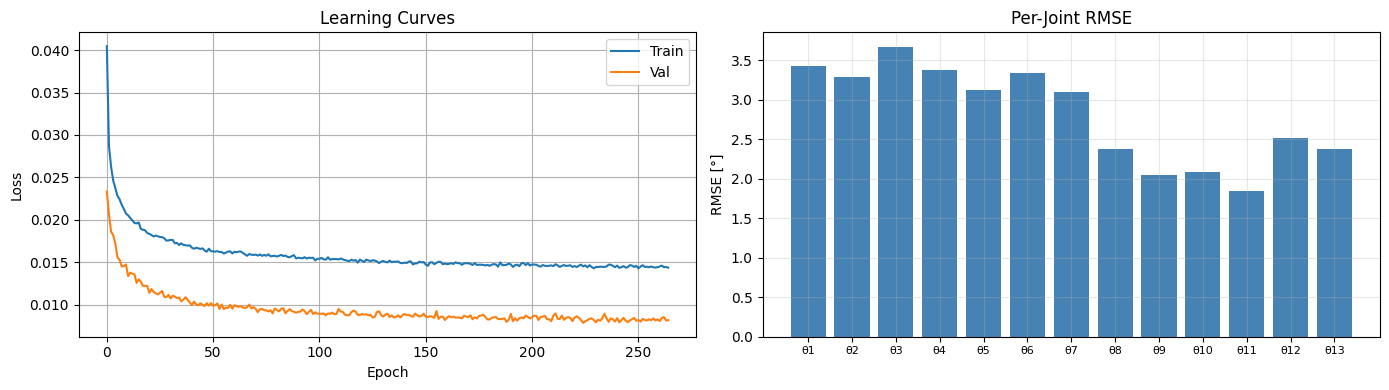


📊 Per-Joint RMSE (Test Set):
   theta_1: RMSE=3.43° | MAE=2.26°
   theta_2: RMSE=3.29° | MAE=2.08°
   theta_3: RMSE=3.67° | MAE=2.22°
   theta_4: RMSE=3.37° | MAE=2.17°
   theta_5: RMSE=3.12° | MAE=2.15°
   theta_6: RMSE=3.34° | MAE=2.23°
   theta_7: RMSE=3.09° | MAE=2.13°
   theta_8: RMSE=2.37° | MAE=1.69°
   theta_9: RMSE=2.05° | MAE=1.39°
   theta_10: RMSE=2.09° | MAE=1.12°
   theta_11: RMSE=1.85° | MAE=1.08°
   theta_12: RMSE=2.52° | MAE=1.35°
   theta_13: RMSE=2.37° | MAE=1.51°

   Mean RMSE: 2.81°


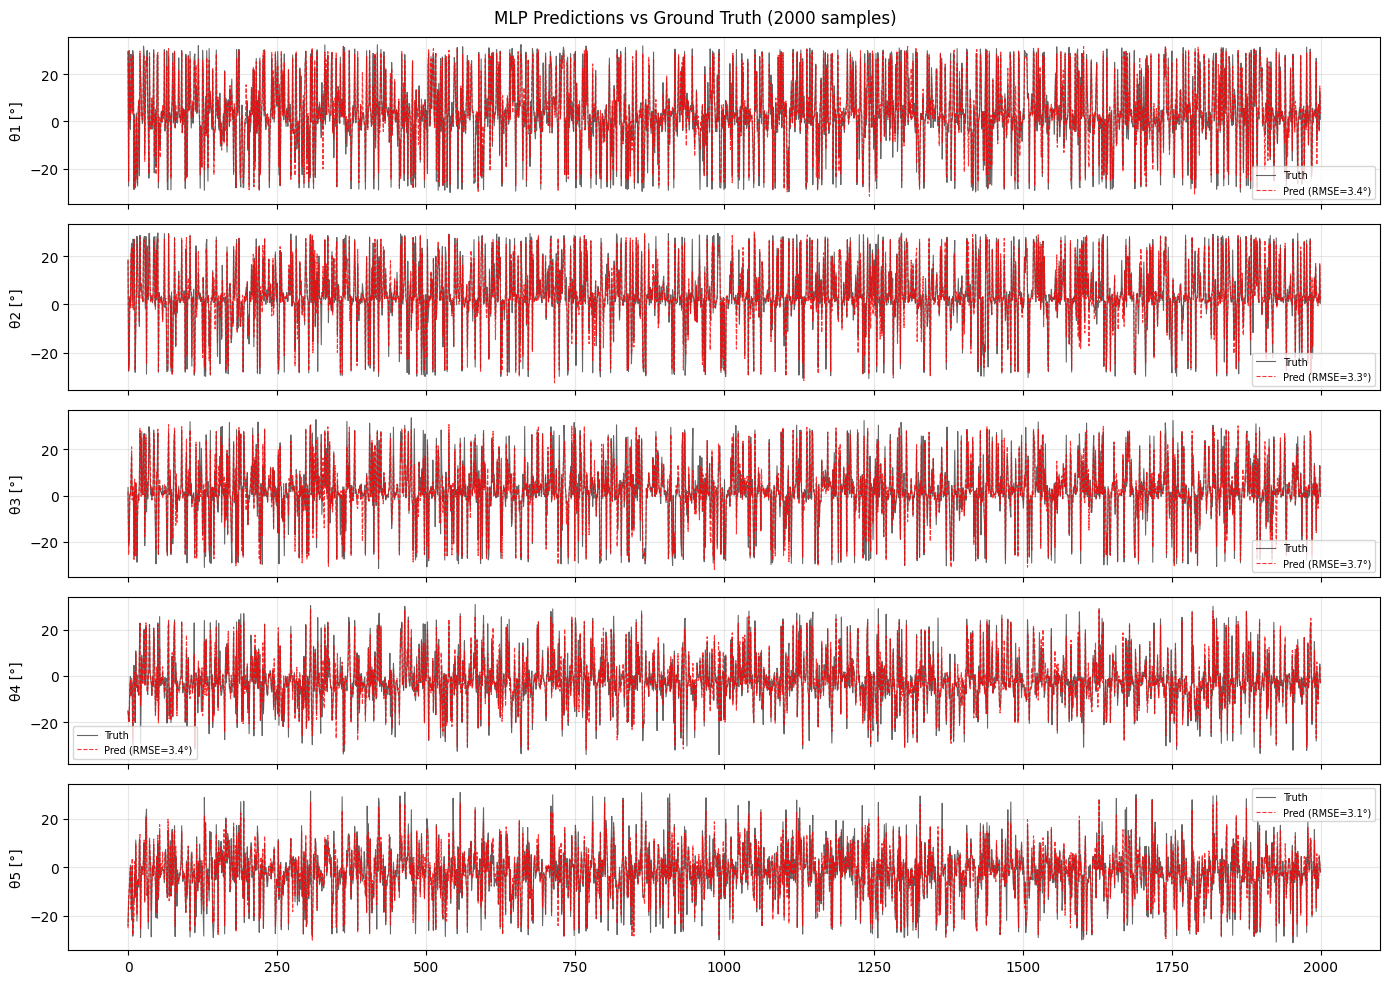

In [297]:
# ==================== EVALUATE ====================

model.eval()
preds = []
with torch.no_grad():
    for X_b, _ in test_loader:
        preds.append(model(X_b.to(device)).cpu().numpy())
y_pred = scaler_y.inverse_transform(np.concatenate(preds))
y_true = scaler_y.inverse_transform(y_test)

# Learning Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(train_losses, label="Train")
axes[0].plot(val_losses, label="Val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True); axes[0].set_title("Learning Curves")

# RMSE per Joint
rmses = [np.sqrt(np.mean((y_pred[:, i] - y_true[:, i])**2)) for i in range(len(THETA_COLS))]
axes[1].bar(range(len(THETA_COLS)), rmses, color='steelblue')
axes[1].set_xticks(range(len(THETA_COLS)))
axes[1].set_xticklabels([f"\u03b8{i+1}" for i in range(len(THETA_COLS))], fontsize=8)
axes[1].set_ylabel("RMSE [°]"); axes[1].set_title("Per-Joint RMSE"); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Print RMSE
print(f"\n\U0001f4ca Per-Joint RMSE (Test Set):")
for i, col in enumerate(THETA_COLS):
    mae = np.mean(np.abs(y_pred[:, i] - y_true[:, i]))
    print(f"   {col}: RMSE={rmses[i]:.2f}° | MAE={mae:.2f}°")
print(f"\n   Mean RMSE: {np.mean(rmses):.2f}°")

# Pred vs Truth (erste 5 Joints)
limit = min(2000, len(y_pred))
fig, axes = plt.subplots(min(5, len(THETA_COLS)), 1, figsize=(14, 10), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(y_true[:limit, i], label="Truth", color="black", alpha=0.6, linewidth=0.8)
    ax.plot(y_pred[:limit, i], label=f"Pred (RMSE={rmses[i]:.1f}°)", color="red", linestyle="--", alpha=0.8, linewidth=0.8)
    ax.set_ylabel(f"\u03b8{i+1} [°]"); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
plt.suptitle(f"MLP Predictions vs Ground Truth ({limit} samples)"); plt.tight_layout(); plt.show()

In [298]:
# ==================== SAVE MODEL ====================

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
layers_str = "x".join(map(str, HIDDEN_LAYERS))
run_name = f"{timestamp}_MLP_{layers_str}_d{DROPOUT_RATE}"
save_path = os.path.join("trained_models", run_name)
os.makedirs(save_path, exist_ok=True)

# Speichern
torch.save(model.state_dict(), os.path.join(save_path, "model.pth"))
joblib.dump(scaler_x_list, os.path.join(save_path, "scaler_x.pkl"))
joblib.dump(scaler_y, os.path.join(save_path, "scaler_y.pkl"))

config = {
    "timestamp": timestamp,
    "model_type": "FeedForward",
    "input_size": input_dim,
    "output_size": output_dim,
    "output_dim": output_dim,
    "hidden_layers": HIDDEN_LAYERS,
    "hidden_size": HIDDEN_LAYERS[0],
    "dropout_rate": DROPOUT_RATE,
    "weight_decay": WEIGHT_DECAY,
    "window_size": 1,
    "learning_rate": LEARNING_RATE,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "final_val_loss": float(best_val_loss),
    "angle_weight_alpha": ANGLE_WEIGHT_ALPHA,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "sensor_features": feature_cols,
    "output_columns": THETA_COLS
}

with open(os.path.join(save_path, "model_config.json"), "w") as f:
    json.dump(config, f, indent=4)

print(f"\U0001f4be Saved to: {save_path}")
print(f"   MLP: {input_dim} → {layers_str} → {output_dim}")
print(f"   Val Loss: {best_val_loss:.5f} | Mean RMSE: {np.mean(rmses):.2f}°")

💾 Saved to: trained_models\2026-02-20_15-00-46_MLP_256x128x64_d0.2
   MLP: 18 → 256x128x64 → 13
   Val Loss: 0.00786 | Mean RMSE: 2.81°


📁 Lade Test-Datensatz: runs/2026-02-10_12-14-57/merged.csv
  → Pivot sensor_id...
✓ Test-Shape: 6908 samples × 62 columns

🔍 NaN-Check: X=0 NaN | Y=542 NaN
   Nach X-NaN-Entfernung: 6908 Zeilen
   Nach Y-NaN-Filter (max 3 NaN/row): 6908 Zeilen
   542 NaN in Y mit 0.0 gefüllt
✓ Test Features: X=(6908, 18) | Y=(6908, 13)

📈 Theta-Bereiche im Test-Set:
   theta_1: -30.7° bis 31.4°
   theta_2: -32.4° bis 30.0°
   theta_3: -32.9° bis 32.6°
   theta_4: -38.2° bis 34.5°
   theta_5: -33.1° bis 36.0°
   theta_6: -33.7° bis 40.5°
   theta_7: -42.2° bis 35.2°
   theta_8: -38.5° bis 34.8°
   theta_9: -39.4° bis 37.2°
   theta_10: -36.6° bis 39.9°
   theta_11: -35.6° bis 36.7°
   theta_12: -37.4° bis 32.0°
   theta_13: -34.5° bis 26.7°

🔄 Skalierung mit Training-Scalers...
✓ Skaliert: X=(6908, 18) | Y=(6908, 13)

🧠 Inferenz auf 6908 Samples...
✓ Vorhersagen: shape=(6908, 13)

📊 Test-Set Performance (Live-Daten: runs/2026-02-10_12-14-57/merged.csv):
   Mean RMSE: 10.45°
   Mean MAE:  7.12°

   Pro G

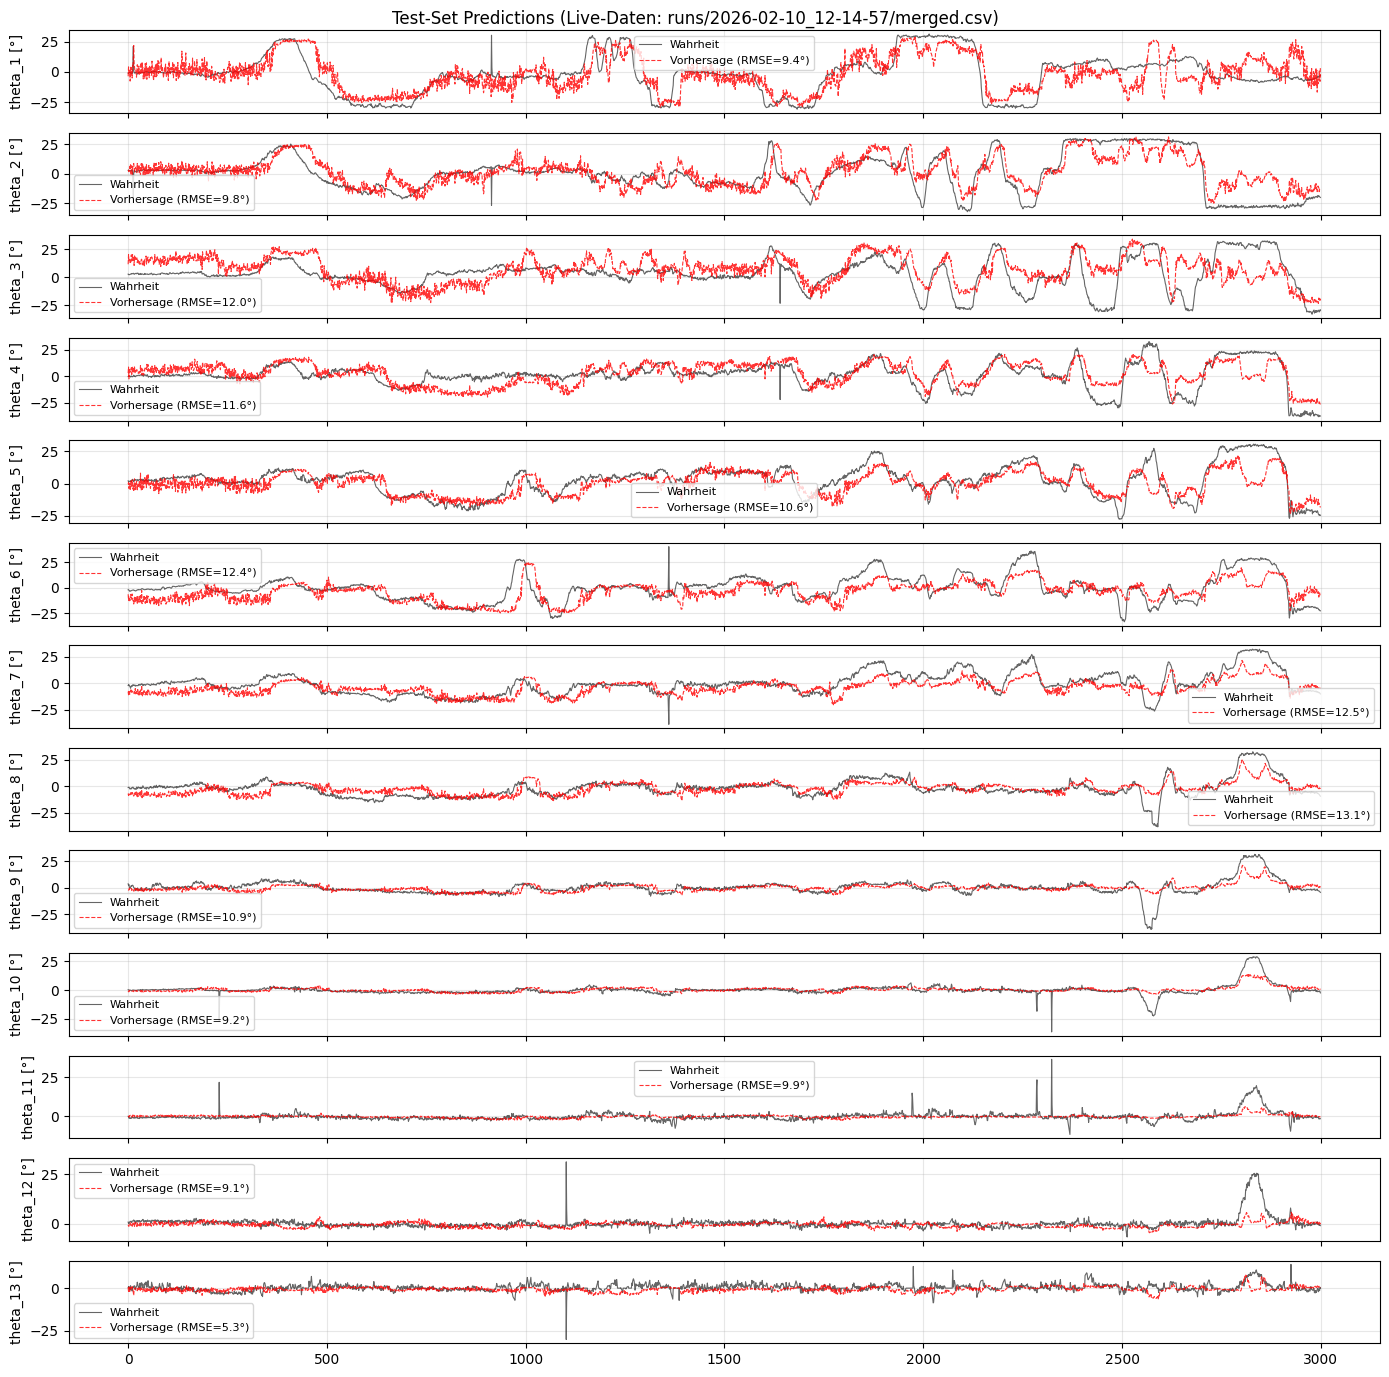


✅ Test abgeschlossen!


In [299]:
# ==================== TEST MIT AUFGENOMMENEM DATENSATZ ====================

# === DATENSATZ LADEN ===
test_data_path = "runs/2026-02-10_12-14-57/merged.csv"
#"runs/2026-02-19_10-14-37/merged_smoothed.csv"
"runs/2026-02-10_12-14-57/merged.csv"  # ← Hier ändern!

print(f"📁 Lade Test-Datensatz: {test_data_path}")
df_test = pl.read_csv(test_data_path)

# Falls noch pivotiert werden muss (sensor_id Spalte existiert)
if "sensor_id" in df_test.columns:
    print("  → Pivot sensor_id...")
    # Cast sensor_id to Int64
    df_test = df_test.with_columns(pl.col("sensor_id").cast(pl.Int64, strict=False))
    
    sensor_ids_test = sorted(df_test["sensor_id"].unique().to_list())
    num_samples_test = len(df_test) // len(sensor_ids_test)
    
    sample_ids_test = np.arange(len(df_test)) // len(sensor_ids_test)
    df_test = df_test.with_columns(pl.Series("sample_id", sample_ids_test))
    
    # Pivot Sensordaten
    sensor_features = [c for c in df_test.columns if c in ["magX", "magY", "magZ", "accX", "accY", "accZ"]]
    
    # Convert sensor features to Float64 before pivoting
    df_test = df_test.with_columns([
        pl.col(c).cast(pl.Float64, strict=False) for c in sensor_features
    ])
    
    pivoted_test = df_test.select(["sample_id", "sensor_id"] + sensor_features).pivot(
        values=sensor_features,
        index="sample_id",
        on="sensor_id",
        aggregate_function="mean"
    ).sort("sample_id")
    
    # Get targets (Gelenkwinkel)
    theta_cols_test = [c for c in df_test.columns if c.startswith("theta_")]
    
    # Convert theta columns to Float64
    df_test = df_test.with_columns([
        pl.col(c).cast(pl.Float64, strict=False) for c in theta_cols_test
    ])
    
    targets_test = df_test.group_by("sample_id", maintain_order=True).agg(
        [pl.col(c).mean() for c in theta_cols_test]
    ).sort("sample_id")
    
    # Join and convert to pandas
    df_test = pivoted_test.join(targets_test, on="sample_id", how="inner").to_pandas()
else:
    df_test = df_test.to_pandas()

# Calculate magnitudes (magMag, accMag) for test data
for sid in sensor_ids:
    mag_cols = [f"mag{ax}_{sid}" for ax in ["X", "Y", "Z"]]
    if all(col in df_test.columns for col in mag_cols):
        df_test[f"magMag_{sid}"] = np.sqrt(df_test[mag_cols[0]]**2 + df_test[mag_cols[1]]**2 + df_test[mag_cols[2]]**2)
    acc_cols = [f"acc{ax}_{sid}" for ax in ["X", "Y", "Z"]]
    if all(col in df_test.columns for col in acc_cols):
        df_test[f"accMag_{sid}"] = np.sqrt(df_test[acc_cols[0]]**2 + df_test[acc_cols[1]]**2 + df_test[acc_cols[2]]**2)

print(f"✓ Test-Shape: {df_test.shape[0]} samples × {df_test.shape[1]} columns")

# === EXTRAHIERE TEST-FEATURES (GLEICHE NaN-BEHANDLUNG WIE TRAINING!) ===
try:
    # Convert to float explicitly
    X_test_live = df_test[feature_cols].astype(float).values
    Y_test_live = df_test[THETA_COLS].astype(float).values
    
    # 🔍 NaN-Check
    n_nan_x = np.isnan(X_test_live).sum()
    n_nan_y = np.isnan(Y_test_live).sum()
    print(f"\n🔍 NaN-Check: X={n_nan_x} NaN | Y={n_nan_y} NaN")
    
    # ⚠️ GLEICHE NaN-BEHANDLUNG WIE TRAINING:
    # 1) Entferne Zeilen mit NaN in X (Sensor-Features)
    valid_x_mask = ~np.isnan(X_test_live).any(axis=1)
    X_test_live = X_test_live[valid_x_mask]
    Y_test_live = Y_test_live[valid_x_mask]
    print(f"   Nach X-NaN-Entfernung: {X_test_live.shape[0]} Zeilen")
    
    # 2) Für Y: Erlaube maximal 3 NaN pro Zeile
    nan_per_row = np.isnan(Y_test_live).sum(axis=1)
    valid_y_mask = nan_per_row <= 3
    X_test_live = X_test_live[valid_y_mask]
    Y_test_live = Y_test_live[valid_y_mask]
    print(f"   Nach Y-NaN-Filter (max 3 NaN/row): {X_test_live.shape[0]} Zeilen")
    
    # 3) Fülle verbleibende NaN in Y mit 0.0
    nan_before = np.isnan(Y_test_live).sum()
    Y_test_live = np.nan_to_num(Y_test_live, nan=0.0)
    if nan_before > 0:
        print(f"   {nan_before} NaN in Y mit 0.0 gefüllt")
    
    print(f"✓ Test Features: X={X_test_live.shape} | Y={Y_test_live.shape}")
    
    # Zeige Theta-Bereiche
    print(f"\n📈 Theta-Bereiche im Test-Set:")
    for i, col in enumerate(THETA_COLS):
        if len(Y_test_live) > 0:
            min_val = Y_test_live[:, i].min()
            max_val = Y_test_live[:, i].max()
            print(f"   {col}: {min_val:.1f}° bis {max_val:.1f}°")
    
except KeyError as e:
    print(f"❌ Fehler: Feature '{e}' nicht im Test-Datensatz!")
    X_test_live = None
except Exception as e:
    print(f"❌ Fehler beim Laden: {e}")
    import traceback
    traceback.print_exc()
    X_test_live = None

# === SKALIERE MIT GLEICHEN SCALERS ===
if X_test_live is not None and len(X_test_live) > 0:
    print(f"\n🔄 Skalierung mit Training-Scalers...")
    
    # Nutze die gleichen scaler_x_list und scaler_y!
    X_test_scaled = np.zeros_like(X_test_live)
    features_per_sensor = len(FEATURE_SELECTION)
    
    for i, scaler in enumerate(scaler_x_list):
        start_idx = i * features_per_sensor
        end_idx = start_idx + features_per_sensor
        X_test_scaled[:, start_idx:end_idx] = scaler.transform(X_test_live[:, start_idx:end_idx])
    
    Y_test_scaled = scaler_y.transform(Y_test_live)
    
    print(f"✓ Skaliert: X={X_test_scaled.shape} | Y={Y_test_scaled.shape}")
    
    # === INFERENZ MIT TRAINIERTEM MODELL ===
    model.eval()
    test_preds = []
    
    print(f"\n🧠 Inferenz auf {len(X_test_scaled)} Samples...")
    with torch.no_grad():
        for i in range(0, len(X_test_scaled), BATCH_SIZE):
            X_batch = torch.FloatTensor(X_test_scaled[i:i+BATCH_SIZE]).to(device)
            y_pred_batch = model(X_batch).cpu().numpy()
            test_preds.append(y_pred_batch)
    
    Y_pred_test_scaled = np.concatenate(test_preds)
    Y_pred_test = scaler_y.inverse_transform(Y_pred_test_scaled)
    
    print(f"✓ Vorhersagen: shape={Y_pred_test.shape}")
    
    # === EVALUIERE ===
    from sklearn.metrics import mean_squared_error, mean_absolute_error
    
    if len(Y_pred_test) > 0:
        # RMSE & MAE Berechnung
        rmse_per_joint = []
        mae_per_joint = []
        
        for i in range(len(THETA_COLS)):
            rmse = np.sqrt(np.mean((Y_test_live[:, i] - Y_pred_test[:, i])**2))
            mae = np.mean(np.abs(Y_test_live[:, i] - Y_pred_test[:, i]))
            rmse_per_joint.append(rmse)
            mae_per_joint.append(mae)
        
        print(f"\n📊 Test-Set Performance (Live-Daten: {test_data_path}):")
        print(f"   Mean RMSE: {np.mean(rmse_per_joint):.2f}°")
        print(f"   Mean MAE:  {np.mean(mae_per_joint):.2f}°")
        print(f"\n   Pro Gelenk:")
        for i, col in enumerate(THETA_COLS):
            print(f"      {col}: RMSE={rmse_per_joint[i]:.2f}° | MAE={mae_per_joint[i]:.2f}°")
        
        # === VISUALISIERE ===
        fig, axes = plt.subplots(min(13, len(THETA_COLS)), 1, figsize=(14, 14), sharex=True)
        if len(THETA_COLS) == 1:
            axes = [axes]
        
        sample_limit = min(3000, len(Y_pred_test))
        
        for i, (ax, col) in enumerate(zip(axes, THETA_COLS[:13])):
            ax.plot(Y_test_live[:sample_limit, i], label="Wahrheit", color="black", alpha=0.6, linewidth=0.8)
            ax.plot(Y_pred_test[:sample_limit, i], label=f"Vorhersage (RMSE={rmse_per_joint[i]:.1f}°)", 
                    color="red", linestyle="--", alpha=0.8, linewidth=0.8)
            ax.set_ylabel(f"{col} [°]")
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)
        
        plt.suptitle(f"Test-Set Predictions (Live-Daten: {test_data_path})")
        plt.tight_layout()
        plt.show()
        
        print(f"\n✅ Test abgeschlossen!")
    else:
        print(f"❌ Keine gültigen Vorhersagen!")
else:
    print(f"❌ Test konnte nicht durchgeführt werden!")


📊 INFERIERTE GELENKWINKEL-ANALYSE

🧠 INFERIERTE DATEN (Vorhersagen):
   Dataset: Y_pred_test shape = (6908, 13)
   theta_1   : min= -46.32° | max=  29.27° | μ=  1.04° | σ= 11.17°
   theta_2   : min= -25.15° | max=  31.49° | μ=  2.35° | σ=  8.74°
   theta_3   : min= -31.61° | max=  34.26° | μ=  3.75° | σ= 10.35°
   theta_4   : min= -28.11° | max=  20.45° | μ= -2.55° | σ= 10.00°
   theta_5   : min= -25.76° | max=  21.40° | μ= -2.50° | σ=  8.49°
   theta_6   : min= -25.92° | max=  24.82° | μ= -3.61° | σ= 10.49°
   theta_7   : min= -22.99° | max=  24.69° | μ= -2.07° | σ=  9.07°
   theta_8   : min= -16.62° | max=  29.37° | μ= -0.63° | σ=  8.11°
   theta_9   : min= -26.94° | max=  26.71° | μ= -0.72° | σ=  7.08°
   theta_10  : min= -32.41° | max=  20.50° | μ= -0.33° | σ=  7.83°
   theta_11  : min=  -6.35° | max=  17.23° | μ= -0.04° | σ=  2.08°
   theta_12  : min=  -6.61° | max=  13.78° | μ= -0.64° | σ=  1.93°
   theta_13  : min=  -6.29° | max=  13.56° | μ=  0.43° | σ=  2.08°


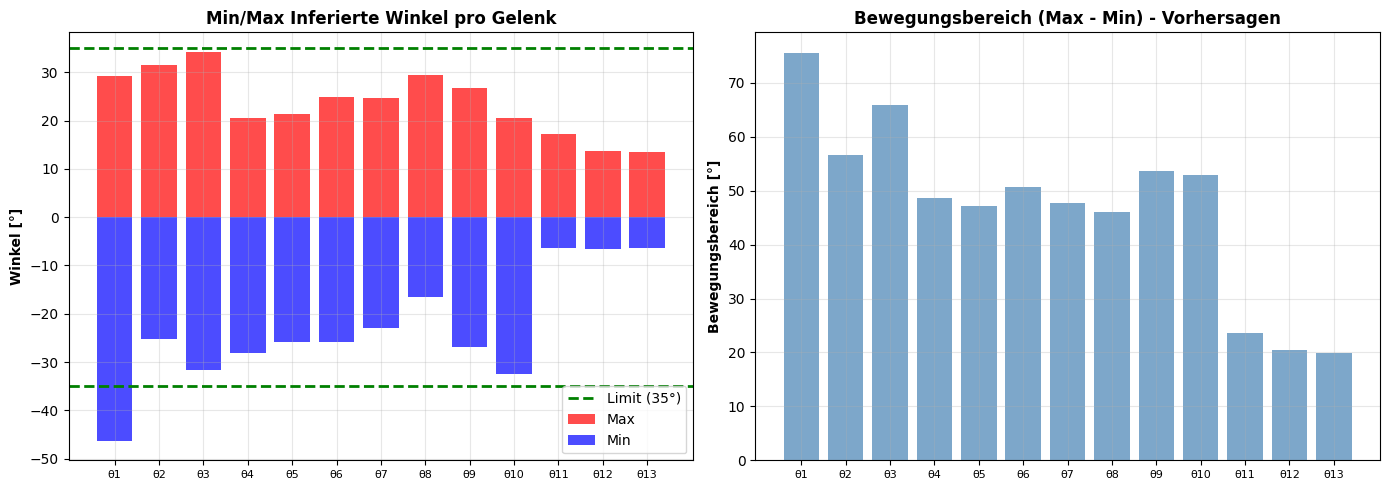


📈 BEWEGUNGSBEREICH PRO GELENK (VORHERSAGEN):
   theta_1: min= -46.32° | max=  29.27° | range= 75.59°
   theta_2: min= -25.15° | max=  31.49° | range= 56.64°
   theta_3: min= -31.61° | max=  34.26° | range= 65.87°
   theta_4: min= -28.11° | max=  20.45° | range= 48.56°
   theta_5: min= -25.76° | max=  21.40° | range= 47.17°
   theta_6: min= -25.92° | max=  24.82° | range= 50.74°
   theta_7: min= -22.99° | max=  24.69° | range= 47.68°
   theta_8: min= -16.62° | max=  29.37° | range= 45.99°
   theta_9: min= -26.94° | max=  26.71° | range= 53.65°
   theta_10: min= -32.41° | max=  20.50° | range= 52.91°
   theta_11: min=  -6.35° | max=  17.23° | range= 23.59°
   theta_12: min=  -6.61° | max=  13.78° | range= 20.40°
   theta_13: min=  -6.29° | max=  13.56° | range= 19.85°

   Größter Bereich: 75.59° (theta_1)
   Kleinster Bereich: 19.85° (theta_13)
   Durchschnittlicher Bereich: 46.82°

✅ Analyse abgeschlossen!


: 

In [ ]:
# ==================== WINKEL-GRENZEN ANALYSE (INFERIERTE DATEN) ====================

print(f"📊 INFERIERTE GELENKWINKEL-ANALYSE")
print(f"{'='*70}")

# Analysiere INFERIERTE Vorhersagen
if 'Y_pred_test' in locals() and len(Y_pred_test) > 0:
    print(f"\n🧠 INFERIERTE DATEN (Vorhersagen):")
    print(f"   Dataset: Y_pred_test shape = {Y_pred_test.shape}")
    
    for i, col in enumerate(THETA_COLS):
        min_val = Y_pred_test[:, i].min()
        max_val = Y_pred_test[:, i].max()
        mean_val = Y_pred_test[:, i].mean()
        std_val = Y_pred_test[:, i].std()
        print(f"   {col:10s}: min={min_val:7.2f}° | max={max_val:7.2f}° | μ={mean_val:6.2f}° | σ={std_val:6.2f}°")
    
    # Visualisiere Min/Max pro Gelenk
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Min/Max Range
    mins = [Y_pred_test[:, i].min() for i in range(len(THETA_COLS))]
    maxs = [Y_pred_test[:, i].max() for i in range(len(THETA_COLS))]
    means = [Y_pred_test[:, i].mean() for i in range(len(THETA_COLS))]
    
    ax = axes[0]
    x_pos = np.arange(len(THETA_COLS))
    ax.bar(x_pos, maxs, label='Max', color='red', alpha=0.7)
    ax.bar(x_pos, mins, label='Min', color='blue', alpha=0.7)
    ax.axhline(y=PHYSICAL_ANGLE_LIMIT, color='green', linestyle='--', linewidth=2, label=f'Limit ({PHYSICAL_ANGLE_LIMIT}°)')
    ax.axhline(y=-PHYSICAL_ANGLE_LIMIT, color='green', linestyle='--', linewidth=2)
    ax.set_ylabel('Winkel [°]', fontweight='bold')
    ax.set_title('Min/Max Inferierte Winkel pro Gelenk', fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f'θ{i+1}' for i in range(len(THETA_COLS))], fontsize=8)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Range (Max-Min)
    ranges = [maxs[i] - mins[i] for i in range(len(THETA_COLS))]
    ax = axes[1]
    ax.bar(x_pos, ranges, color='steelblue', alpha=0.7)
    ax.set_ylabel('Bewegungsbereich [°]', fontweight='bold')
    ax.set_title('Bewegungsbereich (Max - Min) - Vorhersagen', fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f'θ{i+1}' for i in range(len(THETA_COLS))], fontsize=8)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Zusammenfassung
    print(f"\n{'='*70}")
    print(f"📈 BEWEGUNGSBEREICH PRO GELENK (VORHERSAGEN):")
    print(f"{'='*70}")
    for i, col in enumerate(THETA_COLS):
        rang = ranges[i]
        print(f"   {col}: min={mins[i]:7.2f}° | max={maxs[i]:7.2f}° | range={rang:6.2f}°")
    
    print(f"\n   Größter Bereich: {max(ranges):.2f}° ({THETA_COLS[np.argmax(ranges)]})")
    print(f"   Kleinster Bereich: {min(ranges):.2f}° ({THETA_COLS[np.argmin(ranges)]})")
    print(f"   Durchschnittlicher Bereich: {np.mean(ranges):.2f}°")
else:
    print("❌ Y_pred_test nicht verfügbar! Führe erst Cell 10 aus.")

print(f"\n✅ Analyse abgeschlossen!")